In [3]:
from sklearn.datasets import fetch_openml
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

mnist=fetch_openml('mnist_784', as_frame=False)
X,y = mnist['data'], mnist['target']

X_train, X_test, y_train, y_test = X[:60_000], X[60_000:], y[:60_000], y[60_000:]

In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

In [5]:
knn_clf= KNeighborsClassifier()

grid_params = [
    {
        "n_neighbors": [3,4,5,6],
        "weights": ['uniform', 'distance']
    }
]

grid_search = GridSearchCV(knn_clf, grid_params, cv=3, scoring='accuracy')
grid_search.fit(X_train[:10_000], y_train[:10_000])
grid_search.best_params_

{'n_neighbors': 4, 'weights': 'distance'}

In [5]:
grid_search.best_score_

np.float64(0.9397994088551026)

In [6]:
grid_search.best_estimator_.fit(X_train, y_train)
grid_search.score(X_test, y_test)

0.9714

In [7]:
import matplotlib as mpl
import matplotlib.pyplot as plt


def plot_digit(image_data):
    image= image_data.reshape(28,28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")


# 2

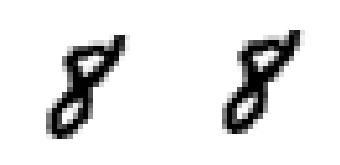

In [7]:
from enum import Enum


def shift_image(img_data, direction='down'):
    img = img_data.reshape(28,28)
    new_img = np.zeros_like(img)

    if direction == 'left':
        new_img[:,1:] = img[:,:-1]
    elif direction == 'right':
        new_img[:,:-1] = img[:,1:]
    elif direction == 'up':
        new_img[:-1,:] = img[1:,:]
    else:
        new_img[1:,:] = img[:-1,:]

    return new_img.flatten()

plt.subplot(131); plot_digit(X_train[17])
plt.subplot(132); plot_digit(shift_image(X_train[17],'up'))
plt.show()





In [9]:
"""new_Xrows, new_Yrows = [],[]
for idx,img_data in enumerate(X_train):    
    for direction in ['left','right', 'up','down']:
        new_Xrows.append(shift_image(img_data, direction))
        new_Yrows.append(

len(new_rows)        
        
#X_train_plus_shift = np.vstack([X_train, new_rows])  
"""

240000

In [10]:
X_train_plus_shift = np.vstack([X_train, new_rows])

In [11]:
X_train_plus_shift.shape

(300000, 784)

In [12]:
#grid_search.best_estimator_.fit(X_train_plus_shift, y_train)

y_train.shape

(60000,)

In [1]:
from scipy.ndimage import shift

In [2]:
def shift_image(image, dx, dy):
    image = image.reshape((28,28))
    shifted_image = shift(image, [dy, dx], cval=0, mode="constant")
    return shifted_image.reshape([-1])

In [9]:
X_train_augmented = [img for img in X_train]    #copy to list
y_train_augmented = [label for label in y_train]

for dx,dy in ((-1,0), (1,0), (0,1),(0, -1)):
    for image, label in zip(X_train, y_train):
        X_train_augmented.append(shift_image(image, dx,dy))
        y_train_augmented.append(label)

X_train_augmented = np.array(X_train_augmented)
y_train_augmented = np.array(y_train_augmented)

In [10]:
#shuffle the augmented dataset to prevent shifted images from being grouped together
shuffle_idx = np.random.permutation(len(X_train_augmented))
X_train_augmented = X_train_augmented[shuffle_idx]
y_train_augmented = y_train_augmented[shuffle_idx]

In [11]:
knn_clf = KNeighborsClassifier(**grid_search.best_params_)

In [12]:
knn_clf.fit(X_train_augmented, y_train_augmented)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",4
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[<U1](10,)","['0','1','2',...,'7','8','9']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [ ]:
augmented_accuracy = knn_clf.score(X_test, y_test)


In [17]:
augmented_accuracy

0.9763

In [22]:
import kagglehub

path=kagglehub.competition_download('titanic')
print(path)

100%|█████████████████████████████████████████████████████████████████████████| 34.1k/34.1k [00:00<00:00, 855kB/s]

Extracting files...
/home/sam/.cache/kagglehub/competitions/titanic


# 3

In [23]:
import pandas as pd
from pathlib import Path

train_st= pd.read_csv(Path(path+"/train.csv"))
test_st = pd.read_csv(Path(path+"/test.csv"))

In [24]:
train_st.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [25]:
train_st.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [29]:
train_st.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [42]:
y_train, X_train = train_st['Survived'], train_st.drop('Survived', axis=1)

In [43]:
X_train.shape

(891, 11)

In [36]:
test_st.describe()


,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [41]:
l1=list(test_st.columns)
l2 = list(train_st.columns)
list( set(l1) ^ set(l2))

['Survived']

In [44]:
train_st['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [45]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [ ]:

pipeline = ColumnTransformer(
    [
        ( "age", SimpleImputer(strategy="median"), ["Age"]),
        ("embarked", SimpleImputer(strategy="most_frequent",["Embarked"]),
         